In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from hotelling.stats import hotelling_t2

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [ ]:
cd C:\Github_repository\Metabolomics_Tutorial\Data

In [4]:
def plot_confidence_ellipse(data, confidence_level=0.90):
    # 중심점 계산
    mean_x, mean_y = np.mean(data, axis=0)
    
    # 공분산 행렬 계산
    cov_matrix = np.cov(data, rowvar=False)
    
    # 고유값 분해
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)
    
    # 신뢰도 수준 스케일링
    # 90% 신뢰 구간을 위해 chi-square 값의 제곱근을 사용 (2차원에서는 약 4.605)
    if confidence_level == 0.95 :
        chi_square_val = 5.991
    elif confidence_level == 0.90 :
        chi_square_val = 4.605
    elif confidence_level == 0.8 :
        chi_square_val = 3.219
    else:
        raise ValueError('CI')

    scale = np.sqrt(chi_square_val)
    
    # 반지름 계산
    width, height = 2 * scale * np.sqrt(eigvals)
    
    # 타원의 회전각 계산 (라디안에서 도 단위로 변환)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    return (mean_x, mean_y), width, height, angle

def cal_ellipse(data, group_name, component1='Component1', componet2='Component2', cl=0.9):
    data = data[data['Group'] == group_name]
    data = data[[component1, componet2]].values

    (mean_x, mean_y), width, height, angle = plot_confidence_ellipse(data, confidence_level=cl)

    return (mean_x, mean_y), width, height, angle

In [ ]:
#Edit

STYPE = 'fecal_neg'
WEEK = '2'

group1 = 'Control'
group2 = 'VNAM'
#group3 = 'Solvent'
#group4 = 'MIA'

## Edit: if your group names are different, change 'Control' and 'VNAM' to the appropriate group names in your dataset.

In [6]:
df = pd.read_excel("dataset_filtered_scaled_merged.xlsx", sheet_name=f'{STYPE}_{WEEK}w', index_col="Label")  #Edit: if your dataset name is different, change 'dataset_filtered_scaled_merged.xlsx' to the appropriate name in your dataset.
df = df.transpose()
df

Label,Group,296.61697-8.708,487.23704-10.048,134.89469-16.398,421.22647-16.397,296.61713-13.231,197.8081-1.761,134.89467-16.9,421.22642-15.939,195.8112-1.798,...,291.73107-0.859,555.02091-1.006,318.8747-0.972,454.84771-0.969,187.02236-1.021,520.83183-0.955,356.91342-0.925,127.00133-1,443.23-9.348,111.08159-9.143
C01_2w,Control,-4.572774,0.067086,1.110949,-0.208549,-2.462796,1.956116,0.444313,1.407484,2.113052,...,0.843714,0.293503,0.421251,0.289999,-0.303579,0.156101,0.7256,0.405881,-1.493018,0.620932
C02_2w,Control,0.223411,0.453396,-0.553325,-0.280528,-2.462796,1.923118,0.130061,1.481465,2.092812,...,0.868264,0.62536,0.990746,0.338911,0.376839,0.534191,-0.122333,0.729615,-0.778087,-0.137926
C03_2w,Control,0.657662,0.402793,-1.168239,-1.001226,-2.462796,2.18281,0.343078,-2.84341,2.412669,...,0.929613,0.1581,-2.623551,1.171263,0.328093,-1.894465,0.264382,0.889764,-0.536311,-3.498776
C04_2w,Control,-0.098263,0.660216,0.095419,0.72464,-2.462796,2.083548,0.661337,1.729332,2.317251,...,0.500311,0.340466,-0.051878,-0.210489,0.439298,0.518628,-0.044398,0.451989,-0.465949,-3.498776
C05_2w,Control,0.496152,0.991129,-0.62486,0.021564,-2.462796,1.352929,0.595437,1.86297,-2.017929,...,0.917359,0.606416,1.22549,0.347164,0.668528,-1.894465,-1.616397,0.711235,0.562218,0.84596
C06_2w,Control,0.948159,0.245269,0.859972,0.014339,1.835018,2.2516,0.228955,-2.84341,2.350784,...,0.330793,-2.919896,-2.623551,1.223844,0.19488,-1.894465,0.118876,-2.675664,0.266093,-0.159258
C07_2w,Control,0.618992,0.808271,-0.493933,-0.897659,1.406076,1.961678,0.200577,-2.84341,2.125492,...,1.070613,-2.919896,0.087669,-0.489573,-1.337377,-1.894465,0.522011,-2.675664,-0.747465,0.334467
C08_2w,Control,0.542554,-1.357107,0.482891,-0.042201,-2.462796,2.226267,0.419024,-2.84341,2.427068,...,1.033744,0.489472,-2.623551,-2.904141,0.389245,-1.894465,0.205893,0.989545,-0.525304,0.22238
C09_2w,Control,1.009734,0.54334,-0.482458,-0.645183,1.875993,1.761642,0.119777,0.698725,1.950364,...,0.954668,-2.919896,-2.623551,-2.904141,0.016598,-1.894465,0.483042,-2.675664,0.910013,0.062217
C10_2w,Control,0.750566,0.909704,0.017413,0.625177,1.637499,-2.214149,0.208679,1.863507,-2.017929,...,-0.010995,-0.114798,1.333299,0.300863,-0.615261,0.811733,-0.092524,0.385367,0.801507,0.517785


In [7]:
df = df[df["Group"] != "QC"].copy()  #Edit: 주석처리하면 QC까지 PCA에 포함됨. QC를 제외하고 PCA를 수행하려면 주석처리 해제.
df

Label,Group,296.61697-8.708,487.23704-10.048,134.89469-16.398,421.22647-16.397,296.61713-13.231,197.8081-1.761,134.89467-16.9,421.22642-15.939,195.8112-1.798,...,291.73107-0.859,555.02091-1.006,318.8747-0.972,454.84771-0.969,187.02236-1.021,520.83183-0.955,356.91342-0.925,127.00133-1,443.23-9.348,111.08159-9.143
C01_2w,Control,-4.572774,0.067086,1.110949,-0.208549,-2.462796,1.956116,0.444313,1.407484,2.113052,...,0.843714,0.293503,0.421251,0.289999,-0.303579,0.156101,0.7256,0.405881,-1.493018,0.620932
C02_2w,Control,0.223411,0.453396,-0.553325,-0.280528,-2.462796,1.923118,0.130061,1.481465,2.092812,...,0.868264,0.62536,0.990746,0.338911,0.376839,0.534191,-0.122333,0.729615,-0.778087,-0.137926
C03_2w,Control,0.657662,0.402793,-1.168239,-1.001226,-2.462796,2.18281,0.343078,-2.84341,2.412669,...,0.929613,0.1581,-2.623551,1.171263,0.328093,-1.894465,0.264382,0.889764,-0.536311,-3.498776
C04_2w,Control,-0.098263,0.660216,0.095419,0.72464,-2.462796,2.083548,0.661337,1.729332,2.317251,...,0.500311,0.340466,-0.051878,-0.210489,0.439298,0.518628,-0.044398,0.451989,-0.465949,-3.498776
C05_2w,Control,0.496152,0.991129,-0.62486,0.021564,-2.462796,1.352929,0.595437,1.86297,-2.017929,...,0.917359,0.606416,1.22549,0.347164,0.668528,-1.894465,-1.616397,0.711235,0.562218,0.84596
C06_2w,Control,0.948159,0.245269,0.859972,0.014339,1.835018,2.2516,0.228955,-2.84341,2.350784,...,0.330793,-2.919896,-2.623551,1.223844,0.19488,-1.894465,0.118876,-2.675664,0.266093,-0.159258
C07_2w,Control,0.618992,0.808271,-0.493933,-0.897659,1.406076,1.961678,0.200577,-2.84341,2.125492,...,1.070613,-2.919896,0.087669,-0.489573,-1.337377,-1.894465,0.522011,-2.675664,-0.747465,0.334467
C08_2w,Control,0.542554,-1.357107,0.482891,-0.042201,-2.462796,2.226267,0.419024,-2.84341,2.427068,...,1.033744,0.489472,-2.623551,-2.904141,0.389245,-1.894465,0.205893,0.989545,-0.525304,0.22238
C09_2w,Control,1.009734,0.54334,-0.482458,-0.645183,1.875993,1.761642,0.119777,0.698725,1.950364,...,0.954668,-2.919896,-2.623551,-2.904141,0.016598,-1.894465,0.483042,-2.675664,0.910013,0.062217
C10_2w,Control,0.750566,0.909704,0.017413,0.625177,1.637499,-2.214149,0.208679,1.863507,-2.017929,...,-0.010995,-0.114798,1.333299,0.300863,-0.615261,0.811733,-0.092524,0.385367,0.801507,0.517785


In [8]:
# 1) y, X 분리
y = df.iloc[:, 0].astype(str)     # Group
X = df.iloc[:, 1:].copy()         # peak area들

# 2) 컬럼명이 str/float 섞인 경우 방지 -> 전부 문자열로 통일
X.columns = X.columns.map(str)

# (선택) 비정상 헤더 제거(빈 헤더/Unnamed가 섞인 경우)
X = X.loc[:, ~X.columns.str.match(r"^Unnamed")]
X = X.loc[:, X.columns != "nan"]

# 3) 숫자화 + 결측 처리
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1, how="all")                 # 전부 NA인 feature 제거
X = X.fillna(X.median(numeric_only=True))       # 중앙값 대치

# 4) (선택) 스케일링 (스케일링을 안한 데이터라면)
#Xz = StandardScaler().fit_transform(X)

Xz = X.copy()

In [9]:
# 5) PCA
pca = PCA(n_components=2, random_state=0)
PC = pca.fit_transform(Xz)
pc1, pc2 = PC[:, 0], PC[:, 1]
evr = pca.explained_variance_ratio_ * 100

In [10]:
# k 선택: 예) 누적 설명분산 80%까지
pca_full = PCA(n_components=min(X.shape[0]-1, X.shape[1]), random_state=0)
PC_all = pca_full.fit_transform(Xz)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k = int(np.searchsorted(cum, 0.80) + 1)   # 80% 기준 (원하면 0.90 등으로 변경)

PCk = PC_all[:, :k]  # PC1..PCk

# Control/VNAM만
mask = y.isin([group1, group2]).values
labs = y.values[mask]
Z = PCk[mask]

Zc = Z[labs == group1]
Zv = Z[labs == group2]

# 조건: (각 그룹 n > k) & (n1+n2-2 > k) 정도는 만족해야 안정적
t2, fval, p_group, S = hotelling_t2(Zc, Zv)

p_txt = f'{p_group:.3e}' if p_group < 0.001 else f'{p_group:.3f}'
p_title = f'{group1} vs. {group2}: p = {p_txt}\n(Week {WEEK}; n = {mask.sum()})'

print(f'PC 1 ~ PC {k} = {cum[k-1]*100:.2f} %')

PC 1 ~ PC 8 = 80.98 %


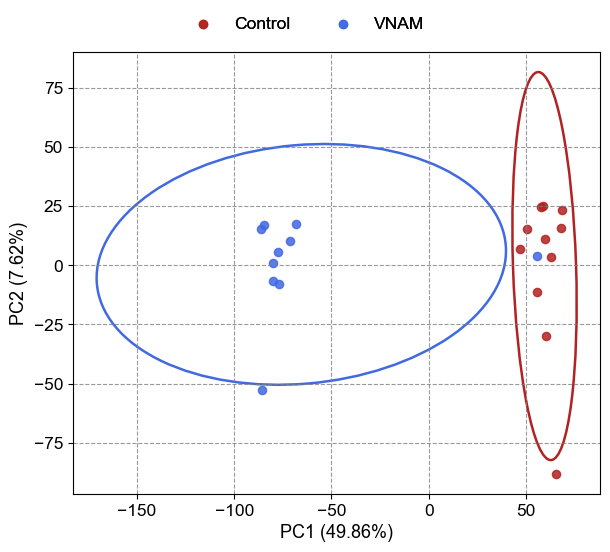

In [12]:
# 6) Plot
# cal_ellipse가 요구하는 형태로 score df 생성
pc_df = pd.DataFrame({"Component1": pc1, "Component2": pc2, "Group": y.values})

color_map = {group1: "firebrick", group2: "royalblue"}
#, group3: "green", group4: "orange"}  #Edit: if your group names are different, change the colors accordingly.

fig, ax = plt.subplots(figsize=(6.2, 5.2))

for g in y.unique():
    idx = (y == g).values
    col = color_map.get(g, "gray")

    ax.scatter(pc1[idx], pc2[idx], s=35, alpha=0.85, color=col,
#               edgecolors=col,
               label=g)

    # (선택) 95% 타원
#    col = sc.get_facecolor()[0]
    # 타원(공분산 기반)
    if idx.sum() >= 3:  ## 표본 너무 적으면 스킵
        (mx, my), w, h, ang = cal_ellipse(pc_df, g, component1="Component1", componet2="Component2", cl=0.95  ## 0.90 / 0.95 / 0.8 중 선택
                                          )
        ell = Ellipse((mx, my), width=w, height=h, angle=ang, facecolor="none", edgecolor=col, linewidth=1.8, zorder=0)
        ax.add_patch(ell)

#ax.axhline(0, linewidth=0.8)
#ax.axvline(0, linewidth=0.8)

plt.xlabel(f'PC1 ({evr[0]:.2f}%)', fontsize=13)
plt.ylabel(f'PC2 ({evr[1]:.2f}%)', fontsize=13)

plt.xticks(fontsize=12.5)
plt.yticks(fontsize=12.5)

#ax.legend(frameon=True)
#ax.set_title("PCA of Metabolomics (colored by Group)")

ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.8, color="gray", alpha=0.8)


# --- (B) 2 Legneds: Group legend + p-value legend ---
# 1) Group legend
leg_groups = fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.98),  ## 위쪽 중앙
                        ncol=len(y.unique()), frameon=False, fontsize=12.5)
ax.add_artist(leg_groups)

# 2) p-value legend
#leg = ax.legend([], [],  # 핸들/라벨 없이 title만
#                title=p_title, loc="upper left", frameon=False, title_fontsize=12.5)
#leg.get_title().set_fontweight('bold')

plt.tight_layout()
plt.savefig(f'pca_{STYPE}_{WEEK}w.png', dpi=500, bbox_inches='tight')
plt.show()

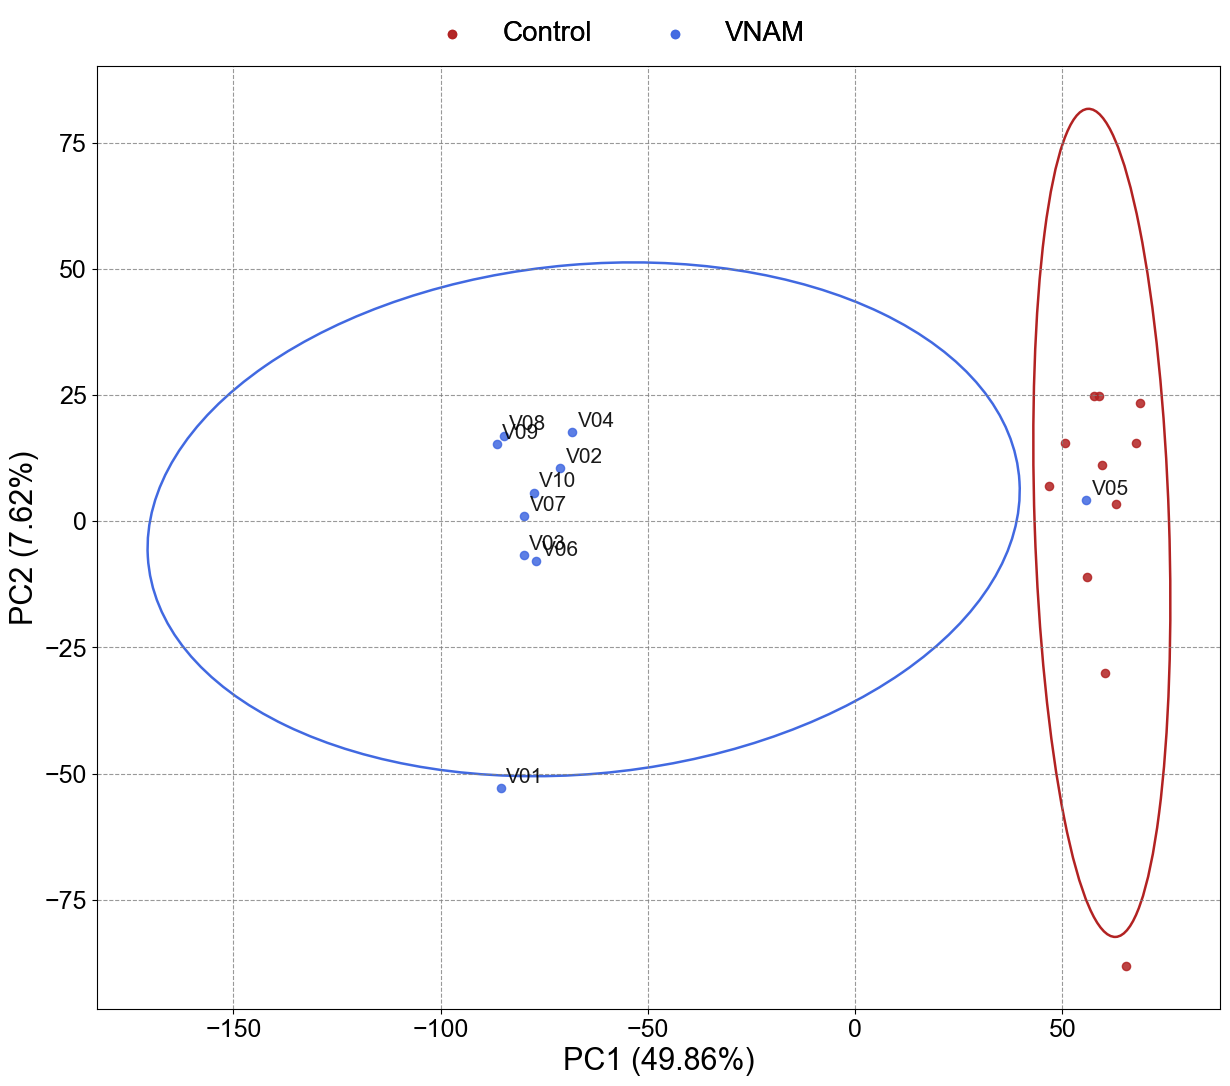

In [13]:
# 6) Plot
# cal_ellipse가 요구하는 형태로 score df 생성
pc_df = pd.DataFrame({"Component1": pc1, "Component2": pc2, "Group": y.values})

color_map = {group1: "firebrick", group2: "royalblue"}
#, group3: "green", group4: "orange", group5: "purple"}  #Edit: if your group names are different, change the colors accordingly.

fig, ax = plt.subplots(figsize=(12.4, 10.4))

for g in y.unique():
    idx = (y == g).values
    col = color_map.get(g, "gray")

    ax.scatter(pc1[idx], pc2[idx], s=35, alpha=0.85, color=col,
#               edgecolors=col,
               label=g)

    # (선택) 95% 타원
#    col = sc.get_facecolor()[0]
    # 타원(공분산 기반)
    if idx.sum() >= 3:  ## 표본 너무 적으면 스킵
        (mx, my), w, h, ang = cal_ellipse(pc_df, g, component1="Component1", componet2="Component2", cl=0.95  ## 0.90 / 0.95 / 0.8 중 선택
                                          )
        ell = Ellipse((mx, my), width=w, height=h, angle=ang, facecolor="none", edgecolor=col, linewidth=1.8, zorder=0)
        ax.add_patch(ell)

#ax.axhline(0, linewidth=0.8)
#ax.axvline(0, linewidth=0.8)

plt.xlabel(f'PC1 ({evr[0]:.2f}%)', fontsize=22)
plt.ylabel(f'PC2 ({evr[1]:.2f}%)', fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

#ax.legend(frameon=True)
#ax.set_title("PCA of Metabolomics (colored by Group)")

ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.8, color="gray", alpha=0.8)


# --- (B) 2 Legneds: Group legend + p-value legend ---
# 1) Group legend
leg_groups = fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.98),  ## 위쪽 중앙
                        ncol=len(y.unique()), frameon=False, fontsize=20)
ax.add_artist(leg_groups)

# 2) p-value legend
#leg = ax.legend([], [],  # 핸들/라벨 없이 title만
#                title=p_title, loc="upper left", frameon=False, title_fontsize=22)
#leg.get_title().set_fontweight('bold')

# Sample annotation: 원하는 그룹만 표시
#label_groups = ['Control']          # Control만
label_groups = ['VNAM']             # VNAM만
#label_groups = ['Control', 'VNAM']  # 둘 다

sample_labels = X.index.astype(str).str.replace(r"_\d+w$", "", regex=True)

for x_coord, y_coord, label, group in zip(pc1, pc2, sample_labels, y.values):
    if group in label_groups:
        ax.annotate(
            label,
            xy=(x_coord, y_coord),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=15,
            alpha=0.9
        )

plt.tight_layout()
plt.savefig(f'pca_{STYPE}_{WEEK}w_annot.png', dpi=500, bbox_inches='tight')
plt.show()

In [14]:
## PCA with raw intensity Data

In [15]:
cd C:\Users\tr432\Desktop\Roh\Command\Github_repository\Metabolomics_Tutorial\Data

C:\Users\tr432\Desktop\Roh\Command\Github_repository\Metabolomics_Tutorial\Data


In [16]:
#Edit

STYPE = 'fecal_neg_2w'

group1 = 'Control'
group2 = 'VNAM'

In [17]:
df = pd.read_excel('dataset_filtered_scaled_merged.xlsx', sheet_name=STYPE, index_col='Label')
df = df.transpose()
df.tail(3)

Label,Group,296.61697-8.708,487.23704-10.048,134.89469-16.398,421.22647-16.397,296.61713-13.231,197.8081-1.761,134.89467-16.9,421.22642-15.939,195.8112-1.798,...,291.73107-0.859,555.02091-1.006,318.8747-0.972,454.84771-0.969,187.02236-1.021,520.83183-0.955,356.91342-0.925,127.00133-1,443.23-9.348,111.08159-9.143
V08_2w,VNAM,0.896026,-1.041567,0.136336,0.851845,1.789133,-2.214149,-1.092397,0.873371,-2.017929,...,-3.008888,1.213525,0.580941,0.458925,0.484468,1.762983,-0.219156,0.240864,0.594503,0.240683
V09_2w,VNAM,0.766784,-1.077987,0.034401,0.826798,1.620294,-2.214149,-1.162507,1.719041,-2.017929,...,-0.270721,1.126579,0.613916,0.675809,0.59448,0.845962,-0.279917,1.08108,1.098527,0.235834
V10_2w,VNAM,0.948976,-1.641813,0.110369,-0.304622,1.880161,-2.214149,-0.258326,1.330351,-2.017929,...,0.694172,1.282125,0.551141,0.427401,0.18945,1.257555,0.444356,0.930098,0.466718,0.252157


In [18]:
df = df[df['Group'] != 'QC'].copy()  #Edit: 주석처리하면 QC까지 PCA에 포함됨. QC를 제외하고 PCA를 수행하려면 주석처리 해제.
df.tail(3)

Label,Group,296.61697-8.708,487.23704-10.048,134.89469-16.398,421.22647-16.397,296.61713-13.231,197.8081-1.761,134.89467-16.9,421.22642-15.939,195.8112-1.798,...,291.73107-0.859,555.02091-1.006,318.8747-0.972,454.84771-0.969,187.02236-1.021,520.83183-0.955,356.91342-0.925,127.00133-1,443.23-9.348,111.08159-9.143
V08_2w,VNAM,0.896026,-1.041567,0.136336,0.851845,1.789133,-2.214149,-1.092397,0.873371,-2.017929,...,-3.008888,1.213525,0.580941,0.458925,0.484468,1.762983,-0.219156,0.240864,0.594503,0.240683
V09_2w,VNAM,0.766784,-1.077987,0.034401,0.826798,1.620294,-2.214149,-1.162507,1.719041,-2.017929,...,-0.270721,1.126579,0.613916,0.675809,0.59448,0.845962,-0.279917,1.08108,1.098527,0.235834
V10_2w,VNAM,0.948976,-1.641813,0.110369,-0.304622,1.880161,-2.214149,-0.258326,1.330351,-2.017929,...,0.694172,1.282125,0.551141,0.427401,0.18945,1.257555,0.444356,0.930098,0.466718,0.252157


In [19]:
# 1) y, X 분리
y = df.iloc[:, 0].astype(str)     # Group
X = df.iloc[:, 1:].copy()         # peak area들

# 2) 컬럼명이 str/float 섞인 경우 방지 -> 전부 문자열로 통일
X.columns = X.columns.map(str)

# (선택) 비정상 헤더 제거(빈 헤더/Unnamed가 섞인 경우)
X = X.loc[:, ~X.columns.str.match(r"^Unnamed")]
X = X.loc[:, X.columns != "nan"]

# 3) 숫자화 + 결측 처리
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1, how="all")                 # 전부 NA인 feature 제거
X = X.fillna(X.median(numeric_only=True))       # 중앙값 대치

# 4) (선택) 스케일링 (스케일링을 안한 데이터라면)
#Xz = StandardScaler().fit_transform(X)

Xz = X.copy()

In [20]:
# 5) PCA
pca = PCA(n_components=2, random_state=0)
PC = pca.fit_transform(Xz)
pc1, pc2 = PC[:, 0], PC[:, 1]
evr = pca.explained_variance_ratio_ * 100

In [21]:
# k 선택: 예) 누적 설명분산 80%까지
pca_full = PCA(n_components=min(X.shape[0]-1, X.shape[1]), random_state=0)
PC_all = pca_full.fit_transform(Xz)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k = int(np.searchsorted(cum, 0.80) + 1)   # 80% 기준 (원하면 0.90 등으로 변경)

PCk = PC_all[:, :k]  # PC1..PCk

# Control/VNAM만
mask = y.isin([group1, group2]).values
labs = y.values[mask]
Z = PCk[mask]

Zc = Z[labs == group1]
Zv = Z[labs == group2]

# 조건: (각 그룹 n > k) & (n1+n2-2 > k) 정도는 만족해야 안정적
t2, fval, p_group, S = hotelling_t2(Zc, Zv)

p_txt = f'{p_group:.3e}' if p_group < 0.001 else f'{p_group:.3f}'
p_title = f'{group1} vs. {group2} : p = {p_txt}\n(Week {WEEK}; n = {mask.sum()})'

print(f'PC 1 ~ PC {k} = {cum[k-1]*100:.2f} %')

PC 1 ~ PC 8 = 80.98 %


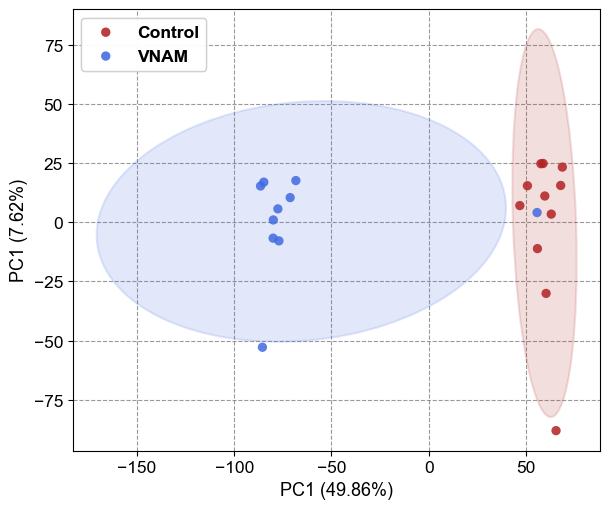

In [22]:
pc_df = pd.DataFrame({'Component1': pc1, 'Component2': pc2, 'Group': y.values})

colors  = {group1: 'firebrick', group2: 'royalblue', 'QC': 'green'}
markers = {group1: 'o', group2: 'o', 'QC': '^'}

orders = ['Control', 'VNAM', 'QC']

DRAW_QC_ELLIPSE = True  ## QC ellipse까지 그리고 싶으면 True
CI = 0.95  #Edit: 0.90 / 0.95 / 0.8

fig, ax = plt.subplots(figsize=(6.2, 5.2))

# 점
for g in y.unique():
    idx = (y == g).values
    col = color_map.get(g, 'gray')

    ax.scatter(pc1[idx], pc2[idx], s=55 if g == 'QC' else 45, alpha=0.9 if g == 'QC' else 0.85, c=colors.get(g, 'gray'), marker=markers.get(g, 'o'), edgecolors='none', label=g, zorder=3)

# ellipse (기본은 group1/group2 만)
for g in y.unique():
    idx = (y == g).values
    col = color_map.get(g, 'gray')

    if g in [group1, group2] or (DRAW_QC_ELLIPSE and g == 'QC'):
        (mx, my), w, h, ang = cal_ellipse(pc_df, g, component1='Component1', componet2='Component2', cl=CI)
        ell = Ellipse((mx, my), width=w, height=h, angle=ang, edgecolor=colors.get(g, 'gray'), facecolor=colors.get(g, 'gray'), linewidth=1.5, alpha=0.15, zorder=2)
        ax.add_patch(ell)

plt.xlabel(f'PC1 ({evr[0]:.2f}%)', fontsize=13)
plt.ylabel(f'PC1 ({evr[1]:.2f}%)', fontsize=13)

plt.xticks(fontsize=12.5)
plt.yticks(fontsize=12.5)

ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.8, color="gray", alpha=0.8)

# 1) Group legend
leg_groups = ax.legend(frameon=True, prop = {'size': 12.5, 'weight': 'bold'})
ax.add_artist(leg_groups)

# 2) p-value legend
#if p_title is not None:
#    ax.legend([], [], title=p_title, loc='lower left', frameon=False, title_fontsize=11)

plt.tight_layout()
#plt.savefig("pca_merged.png", dpi=500, bbox_inches='tight')
plt.show()